# Advanced Features for Production Systems

This notebook demonstrates best practices and production-ready patterns for using Fast BOCPD in real-world applications.

## What You'll Learn

- Using `OnlineChangeDetector` for robust real-time detection
- Extracting and analyzing segments
- Managing detector state (reset, resume)
- Handling edge cases and data quality issues
- Production deployment patterns

## Prerequisites

Complete tutorials 01-04.

---

## Setup

Import libraries and helper functions.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

from fast_bocpd import BOCPD, GaussianNIG, ConstantHazard, OnlineChangeDetector

print("Libraries loaded successfully")

Libraries loaded successfully


---
## 1. OnlineChangeDetector: The Production Wrapper

For real-world applications, use `OnlineChangeDetector` instead of raw BOCPD. It provides:

- Automatic changepoint detection (no manual thresholding)
- Built-in history tracking
- Segment extraction
- Metadata support

### Basic Usage Pattern

**Critical:** Set `lambda_` to match your expected segment length. If `lambda_` is too large, the algorithm will be conservative and may miss changepoints. If too small, it may report false positives.

In [2]:
# Initialize BOCPD
model = GaussianNIG(mu0=0.0, kappa0=1.0, alpha0=1.0, beta0=1.0)
hazard = ConstantHazard(lambda_=70)  # Match minimum expected segment length
bocpd = BOCPD(model, hazard, max_run_length=250)

# Wrap with OnlineChangeDetector
detector = OnlineChangeDetector(
    bocpd, 
    min_confidence=0.3  # Only report CPs with >30% confidence
)

print(f"Detector initialized with min_confidence={detector.min_confidence}")
print(f"Expected segment length (lambda): {hazard.lambda_}")
print(f"Current run length: {detector.get_current_run_length()}")

Detector initialized with min_confidence=0.3
Expected segment length (lambda): 70.0
Current run length: 0


---
## 2. Real-Time Streaming Pattern

Simulate processing a live data stream with metadata tracking.

In [3]:
np.random.seed(42)

# Segment lengths: 100, 80, 70 (average ~83)
data = np.concatenate([
    np.random.randn(100) * 0.7 + 10.0,
    np.random.randn(80) * 0.4 + 19.0,
    np.random.randn(70) * 0.2 + 3.0
])

# Simulate timestamps (1 observation per second)
start_time = datetime(2024, 1, 1, 0, 0, 0)
timestamps = [start_time + timedelta(seconds=i) for i in range(len(data))]

print(f"Simulating {len(data)} observations from {timestamps[0]} to {timestamps[-1]}")
print(f"True changepoints at indices: 100, 180")
print(f"Segment lengths: 100, 80, 70 (average: {(100+80+70)/3:.0f})")

Simulating 250 observations from 2024-01-01 00:00:00 to 2024-01-01 00:04:09
True changepoints at indices: 100, 180
Segment lengths: 100, 80, 70 (average: 83)


In [4]:
# Process stream with metadata
print("Processing stream...\n")

changepoints_detected = []

for t, (timestamp, value) in enumerate(zip(timestamps, data)):
    # Attach metadata to each observation
    metadata = {
        'timestamp': timestamp,
        'sensor_id': 'SENSOR_01',
        'index': t
    }
    
    # Update detector
    changepoint = detector.update(value, metadata=metadata)
    
    # Handle changepoint detection
    if changepoint:
        print(f"Changepoint detected!")
        print(f"  Time: {changepoint.metadata['timestamp']}")
        print(f"  Index: {changepoint.index}")
        print(f"  Confidence: {changepoint.confidence:.1%}")
        print(f"  Previous segment lasted: {changepoint.prev_run_length} observations")
        print(f"  Trigger value: {changepoint.observation:.2f}\n")
        
        changepoints_detected.append(changepoint)

print(f"Total changepoints detected: {len(changepoints_detected)}")

Processing stream...

Changepoint detected!
  Time: 2024-01-01 00:01:40
  Index: 100
  Confidence: 99.3%
  Previous segment lasted: 100 observations
  Trigger value: 18.43

Changepoint detected!
  Time: 2024-01-01 00:03:00
  Index: 180
  Confidence: 99.8%
  Previous segment lasted: 80 observations
  Trigger value: 3.13

Total changepoints detected: 2


---
## 3. Segment Analysis

Extract and analyze the segments between changepoints.

In [5]:
# Get all detected changepoints
changepoints = detector.get_changepoints()

# Get segments
segments = detector.get_segments()

print(f"Detected {len(segments)} segments:\n")
print(f"{'Segment':<10} {'Start':<8} {'End':<8} {'Length':<10} {'Mean':<10} {'Std':<10}")
print("-" * 60)

for i, (start, end) in enumerate(segments, 1):
    segment_data = data[start:end]
    print(f"{i:<10} {start:<8} {end:<8} {end-start:<10} "
          f"{segment_data.mean():<10.2f} {segment_data.std():<10.2f}")

# Access metadata for changepoints
if len(changepoints) > 0:
    print(f"\nFirst changepoint timestamp: {changepoints[0].metadata['timestamp']}")

Detected 3 segments:

Segment    Start    End      Length     Mean       Std       
------------------------------------------------------------
1          0        100      100        9.93       0.63      
2          100      180      80         19.03      0.40      
3          180      250      70         3.01       0.20      

First changepoint timestamp: 2024-01-01 00:01:40


---
## 4. Visualizing Detection Results

Create a comprehensive visualization of segments and changepoints.

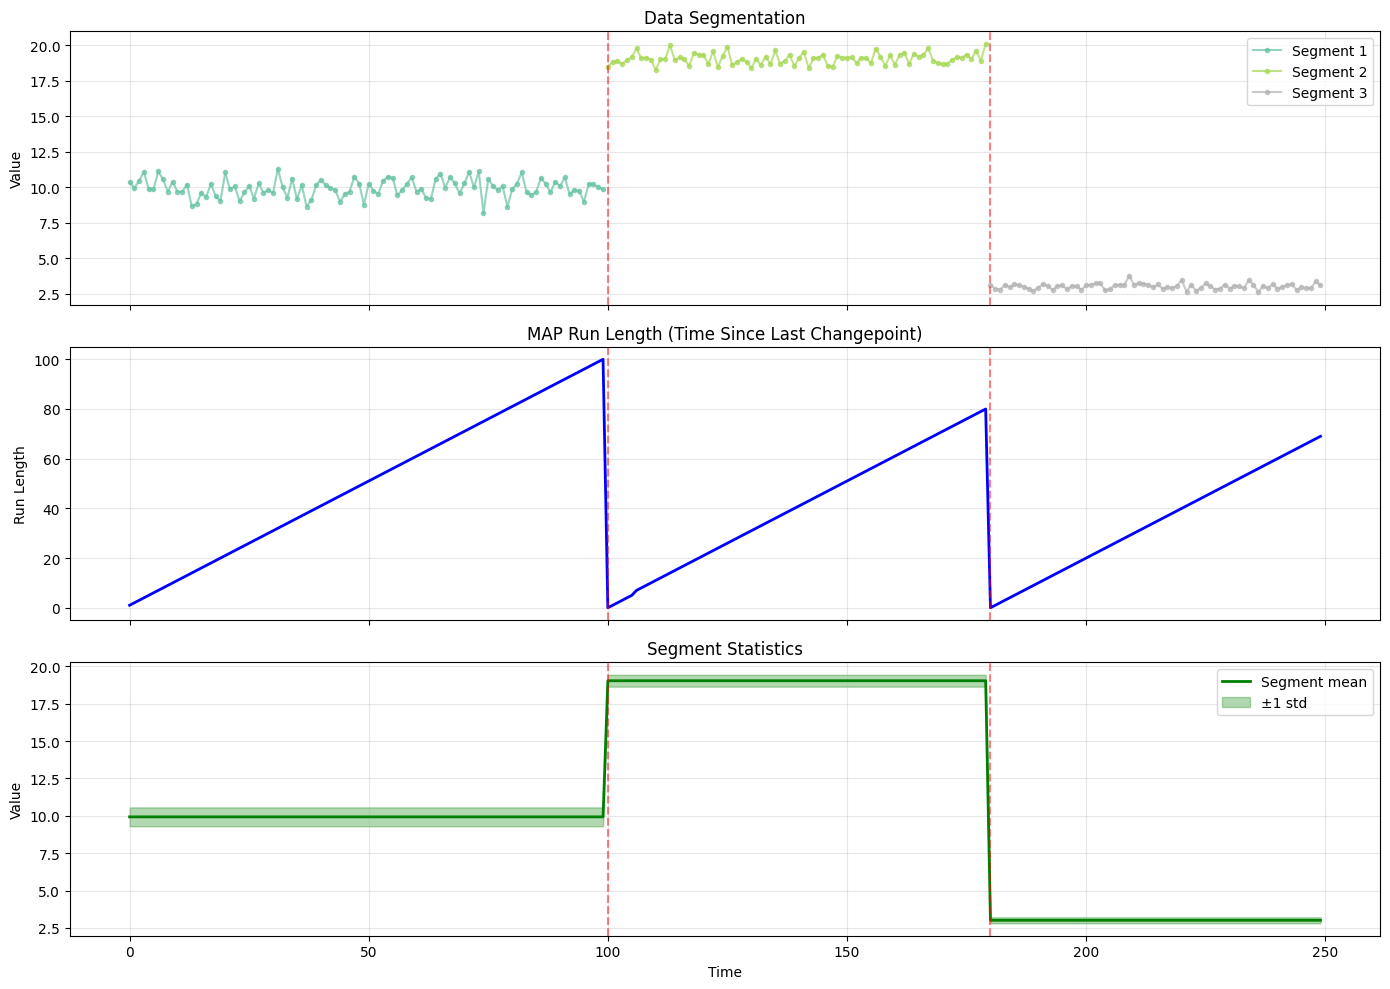

In [6]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# Plot 1: Data with segments colored
colors = plt.cm.Set2(np.linspace(0, 1, len(segments)))
for i, (start, end) in enumerate(segments):
    ax1.plot(range(start, end), data[start:end], 'o-', 
             color=colors[i], alpha=0.7, markersize=3, label=f'Segment {i+1}')

# Mark changepoints
for cp in changepoints:
    ax1.axvline(cp.index, color='red', linestyle='--', alpha=0.5, linewidth=1.5)

ax1.set_ylabel('Value')
ax1.set_title('Data Segmentation')
ax1.legend(loc='best')
ax1.grid(True, alpha=0.3)

# Plot 2: Run length over time
map_history = detector.get_map_history()
ax2.plot(map_history, linewidth=2, color='blue')
for cp in changepoints:
    ax2.axvline(cp.index, color='red', linestyle='--', alpha=0.5, linewidth=1.5)
ax2.set_ylabel('Run Length')
ax2.set_title('MAP Run Length (Time Since Last Changepoint)')
ax2.grid(True, alpha=0.3)

# Plot 3: Segment statistics over time
segment_means = []
segment_stds = []
for i in range(len(data)):
    # Find which segment this observation belongs to
    for seg_idx, (start, end) in enumerate(segments):
        if start <= i < end:
            segment_means.append(data[start:end].mean())
            segment_stds.append(data[start:end].std())
            break

ax3.plot(segment_means, linewidth=2, color='green', label='Segment mean')
ax3.fill_between(range(len(segment_means)), 
                  np.array(segment_means) - np.array(segment_stds),
                  np.array(segment_means) + np.array(segment_stds),
                  alpha=0.3, color='green', label='±1 std')
for cp in changepoints:
    ax3.axvline(cp.index, color='red', linestyle='--', alpha=0.5, linewidth=1.5)
ax3.set_xlabel('Time')
ax3.set_ylabel('Value')
ax3.set_title('Segment Statistics')
ax3.legend()
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 5. State Management: Reset and Resume

In production, you may need to reset or save/restore detector state.

### Reset: Start Fresh

In [7]:
print("Before reset:")
print(f"  Observations processed: {len(detector.get_map_history())}")
print(f"  Changepoints detected: {len(detector.get_changepoints())}")
print(f"  Current run length: {detector.get_current_run_length()}")

# Reset detector to initial state
detector.reset()

print("\nAfter reset:")
print(f"  Observations processed: {len(detector.get_map_history())}")
print(f"  Changepoints detected: {len(detector.get_changepoints())}")
print(f"  Current run length: {detector.get_current_run_length()}")

print("\nUse reset() when:")
print("  - Starting a new data stream")
print("  - Clearing accumulated history")
print("  - Recovering from errors")

Before reset:
  Observations processed: 250
  Changepoints detected: 2
  Current run length: 69

After reset:
  Observations processed: 0
  Changepoints detected: 0
  Current run length: 0

Use reset() when:
  - Starting a new data stream
  - Clearing accumulated history
  - Recovering from errors


---
## 6. Handling Edge Cases

Real-world data has issues. Here's how to handle them.

### 6.1 Missing Data (NaN values)

In [8]:
# Reinitialize detector
model = GaussianNIG(mu0=0.0, kappa0=1.0, alpha0=1.0, beta0=1.0)
hazard = ConstantHazard(lambda_=50)
bocpd = BOCPD(model, hazard, max_run_length=150)
detector = OnlineChangeDetector(bocpd, min_confidence=0.3)

# Data stream with missing values
data_with_gaps = np.concatenate([
    np.random.randn(30) * 0.5 + 0.0,
    [np.nan] * 5,  # Missing data
    np.random.randn(30) * 0.5 + 5.0
])

print("Handling missing data:\n")

for t, x in enumerate(data_with_gaps):
    if np.isnan(x):
        print(f"  t={t}: Skipping NaN")
        continue  # Skip missing values
    
    cp = detector.update(x)
    if cp:
        print(f"  t={t}: Changepoint detected")

print(f"\nProcessed {len(detector.get_map_history())} valid observations")
print(f"Skipped {np.sum(np.isnan(data_with_gaps))} NaN values")

Handling missing data:

  t=30: Skipping NaN
  t=31: Skipping NaN
  t=32: Skipping NaN
  t=33: Skipping NaN
  t=34: Skipping NaN
  t=35: Changepoint detected

Processed 60 valid observations
Skipped 5 NaN values


### 6.2 Outliers and Data Quality

In [9]:
# Reset detector
detector.reset()

# Data with outliers
np.random.seed(123)
data_with_outliers = np.random.randn(100) * 0.5 + 10.0
data_with_outliers[30] = 100.0  # Extreme outlier
data_with_outliers[60] = -50.0  # Another outlier

print("Strategy 1: Detect and skip outliers\n")

def is_outlier(x, window, threshold=5.0):
    """Simple outlier detection: >threshold standard deviations from window mean"""
    if len(window) < 5:
        return False
    mean = np.mean(window)
    std = np.std(window)
    return abs(x - mean) > threshold * std

window_buffer = []
outliers_detected = 0

for t, x in enumerate(data_with_outliers):
    # Check if outlier
    if is_outlier(x, window_buffer, threshold=5.0):
        print(f"  t={t}: Outlier detected (x={x:.2f}), skipping")
        outliers_detected += 1
        continue
    
    # Update detector with clean data
    detector.update(x)
    
    # Maintain sliding window for outlier detection
    window_buffer.append(x)
    if len(window_buffer) > 20:
        window_buffer.pop(0)

print(f"\nOutliers detected and skipped: {outliers_detected}")
print(f"Clean observations processed: {len(detector.get_map_history())}")

Strategy 1: Detect and skip outliers

  t=30: Outlier detected (x=100.00), skipping
  t=60: Outlier detected (x=-50.00), skipping

Outliers detected and skipped: 2
Clean observations processed: 98


### 6.3 Very Long Segments

If segments are longer than `max_run_length`, detection can degrade.

In [10]:
# Detector with small max_run_length
model = GaussianNIG(mu0=0.0, kappa0=1.0, alpha0=1.0, beta0=1.0)
hazard = ConstantHazard(lambda_=50)
bocpd_small = BOCPD(model, hazard, max_run_length=100)
detector_small = OnlineChangeDetector(bocpd_small, min_confidence=0.3)

# Data with very long segment (150 observations)
data_long = np.concatenate([
    np.random.randn(150) * 0.5 + 0.0,
    np.random.randn(50) * 0.5 + 5.0
])

for x in data_long:
    detector_small.update(x)

print("Warning: Long segment (150 obs) with max_run_length=100")
print(f"Current run length: {detector_small.get_current_run_length()}")
print(f"Changepoints detected: {len(detector_small.get_changepoints())}")

print("\nBest practice:")
print("  Set max_run_length >= 3 × expected_segment_length")
print(f"  For λ=50, use max_run_length >= 150")

Current run length: 50
Changepoints detected: 1

Best practice:
  Set max_run_length >= 3 × expected_segment_length
  For λ=50, use max_run_length >= 150


---
## 7. Production Deployment Patterns

### 7.1 Streaming API Pattern

In [11]:
class ChangePointMonitor:
    """Production-ready changepoint monitoring system"""
    
    def __init__(self, lambda_=100, min_confidence=0.3):
        model = GaussianNIG(mu0=0.0, kappa0=1.0, alpha0=1.0, beta0=1.0)
        hazard = ConstantHazard(lambda_=lambda_)
        bocpd = BOCPD(model, hazard, max_run_length=3*lambda_)
        
        self.detector = OnlineChangeDetector(bocpd, min_confidence=min_confidence)
        self.callbacks = []
    
    def register_callback(self, callback_fn):
        """Register function to call when changepoint detected"""
        self.callbacks.append(callback_fn)
    
    def process_observation(self, value, metadata=None):
        """Process single observation"""
        # Handle invalid data
        if not np.isfinite(value):
            return None
        
        # Update detector
        cp = self.detector.update(value, metadata=metadata)
        
        # Trigger callbacks if changepoint detected
        if cp:
            for callback in self.callbacks:
                callback(cp)
        
        return cp
    
    def get_current_state(self):
        """Get current monitoring state"""
        return {
            'run_length': self.detector.get_current_run_length(),
            'total_changepoints': len(self.detector.get_changepoints()),
            'observations_processed': len(self.detector.get_map_history())
        }

# Example usage
def alert_callback(changepoint):
    print(f"ALERT: Changepoint at index {changepoint.index}, "
          f"confidence {changepoint.confidence:.1%}")

monitor = ChangePointMonitor(lambda_=50, min_confidence=0.4)
monitor.register_callback(alert_callback)

# Simulate streaming
print("Streaming data to monitor:\n")
test_data = np.concatenate([
    np.random.randn(50) * 2 + 0.0,
    np.random.randn(50) * 0.5 + 10.0
])

for i, x in enumerate(test_data):
    monitor.process_observation(x, metadata={'index': i})

print(f"\nFinal state: {monitor.get_current_state()}")

Streaming data to monitor:


Final state: {'run_length': 50, 'total_changepoints': 0, 'observations_processed': 100}


### 7.2 Batch Processing with Progress Tracking

In [12]:
def batch_detect_changepoints(data, lambda_=100, min_confidence=0.3, verbose=True):
    """
    Process batch data with progress reporting.
    
    Returns:
        changepoints: List of detected changepoints
        segments: List of (start, end) tuples
    """
    model = GaussianNIG(mu0=0.0, kappa0=1.0, alpha0=1.0, beta0=1.0)
    hazard = ConstantHazard(lambda_=lambda_)
    bocpd = BOCPD(model, hazard, max_run_length=3*lambda_)
    detector = OnlineChangeDetector(bocpd, min_confidence=min_confidence)
    
    n = len(data)
    report_every = max(1, n // 10)  # Report every 10%
    
    for i, x in enumerate(data):
        if verbose and i % report_every == 0:
            print(f"Progress: {100*i/n:.0f}% ({i}/{n} observations)")
        
        detector.update(x)
    
    if verbose:
        print(f"Progress: 100% ({n}/{n} observations)")
        print(f"Detected {len(detector.get_changepoints())} changepoints")
    
    return detector.get_changepoints(), detector.get_segments()

# Example
np.random.seed(42)
large_dataset = np.concatenate([
    np.random.randn(1000) * 0.5 + 0.0,
    np.random.randn(800) * 0.5 + 3.0,
    np.random.randn(1200) * 0.5 + -2.0
])

print("Processing large dataset:\n")
changepoints, segments = batch_detect_changepoints(
    large_dataset, 
    lambda_=500, 
    min_confidence=0.3
)

print(f"\nResults: {len(segments)} segments identified")

Processing large dataset:

Progress: 0% (0/3000 observations)
Progress: 10% (300/3000 observations)
Progress: 20% (600/3000 observations)
Progress: 30% (900/3000 observations)
Progress: 40% (1200/3000 observations)
Progress: 50% (1500/3000 observations)
Progress: 60% (1800/3000 observations)
Progress: 70% (2100/3000 observations)
Progress: 80% (2400/3000 observations)
Progress: 90% (2700/3000 observations)
Progress: 100% (3000/3000 observations)
Detected 3 changepoints

Results: 4 segments identified


---
## 8. Best Practices Summary

### Configuration

**1. Set lambda appropriately**
```python
# Estimate from domain knowledge or historical data
expected_segment_length = 100
lambda_ = expected_segment_length
```

**2. Set max_run_length with safety margin**
```python
# Rule: 3-5× lambda
max_run_length = 3 * lambda_  # Conservative
max_run_length = 5 * lambda_  # Very safe
```

**3. Tune min_confidence**
```python
# High confidence → fewer false positives
min_confidence = 0.5  # Conservative

# Low confidence → catch more changepoints
min_confidence = 0.2  # Sensitive
```

### Data Quality

**4. Handle missing data**
```python
if np.isnan(x):
    continue  # Skip NaNs
```

**5. Detect outliers**
```python
if is_outlier(x):
    continue  # Skip or cap outliers
```

**6. Standardize data when possible**
```python
data_std = (data - data.mean()) / data.std()
# Use default GaussianNIG priors
```

### Production

**7. Use OnlineChangeDetector**
- Simpler API than raw BOCPD
- Built-in history tracking
- Metadata support

**8. Implement callbacks for real-time alerts**
```python
detector.update(x, metadata={'timestamp': now})
if changepoint:
    trigger_alert(changepoint)
```

**9. Monitor system health**
```python
state = detector.get_current_state()
log_metrics(state)
```

**10. Plan for state management**
- Reset when starting new streams
- Consider persistence for resuming

---

## Summary

### Key Takeaways

**OnlineChangeDetector is production-ready:**
- Automatic detection using MAP
- Built-in confidence filtering
- Metadata tracking
- Segment extraction

**Handle real-world issues:**
- Missing data → skip NaNs
- Outliers → detect and filter
- Long segments → increase max_run_length

**Production patterns:**
- Callback-based alerting
- Progress tracking for batch
- State management
- Standardized data preprocessing

### Next Steps

**06_real_world_us30_volatility.ipynb:** See these patterns applied to real financial data

**You're ready to deploy BOCPD in production!**

---